# НИРМ3 — неделя 5: baseline 1D-CNN на PTB-XL

Продолжение `nirm3_week4_ptbxl.ipynb` (использует кэш недель 3–4: предобработанные сигналы,
статистику нормировки, метки и разбиение, предсказания XGBoost).

Задачи недели 5:
1. Baseline 1D-CNN (остаточная сеть `ResNet1d` в варианте Wang et al., как `resnet1d_wang` в
   бенчмарке PTB-XL) на `records100`, обучение на фолдах 1–8, выбор эпохи по фолду 9.
2. Оценка по протоколу недели 4: macro-AUC и AUC по классам на фолде 10 с бутстреп-интервалами,
   отдельно по полу, порог скрининга с чувствительностью ≥ 0.90.
3. Сравнение с классическим baseline недели 4 (XGBoost) — парный бутстреп на одних и тех же записях.
4. Абляция нормировки: глобальная по фолдам 1–8 против z-score каждой записи (проверка вывода
   недели 3 о вольтажных признаках HYP уже на нейросети).

`seed=42`, PTB-XL v1.0.3, `records100`, CPU.

In [1]:
%pip install wfdb --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import ast
import glob
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score

SEED = 42
DATA_PATH = os.path.dirname(glob.glob('**/ptbxl_database.csv', recursive=True)[0]) + os.sep
CACHE = 'cache' + os.sep
FIG_DIR = CACHE + 'fig' + os.sep
assert os.path.exists(CACHE + 'labels_splits.npz'), 'сначала выполните ноутбуки недель 3 и 4'
plt.rcParams.update({'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch {torch.__version__}, device {DEVICE}, threads {torch.get_num_threads()}')

df = pd.read_csv(DATA_PATH + 'ptbxl_database.csv', index_col='ecg_id')
df['sex_label'] = df.sex.map({0: 'male', 1: 'female'})
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

X = np.load(CACHE + 'X100_bp05-40_crop.npy')
prep = json.load(open(CACHE + 'preprocessing.json'))
lab = np.load(CACHE + 'labels_splits.npz', allow_pickle=True)
Y, split, has_label = lab['Y'].astype(np.float32), lab['split'], lab['has_label']
assert (lab['ecg_ids'] == df.index.to_numpy()).all()
tr, va, te = [(split == s) & has_label for s in ('train', 'val', 'test')]
sex_te = df.sex_label.to_numpy()[te]
print(f'train {tr.sum()}, val {va.sum()}, test {te.sum()}; X {X.shape}')

torch 2.14.1+cpu, device cpu, threads 14


train 17084, val 2146, test 2158; X (21799, 900, 12)


## Протокол оценки (без изменений с недели 4)

In [3]:
N_BOOT = 1000
TARGET_SENS = 0.90


def macro_auc(y, s):
    return np.mean([roc_auc_score(y[:, k], s[:, k]) for k in range(y.shape[1])])


def bootstrap_ci(y, s, metric=macro_auc, n=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if (y[idx].sum(axis=0) > 0).all() and (y[idx].sum(axis=0) < len(idx)).all():
            vals.append(metric(y[idx], s[idx]))
    return np.percentile(vals, [2.5, 97.5])


def screening_thresholds(y_val, s_val, target=TARGET_SENS):
    th = []
    for k in range(y_val.shape[1]):
        pos_scores = np.sort(s_val[y_val[:, k] == 1, k])
        th.append(pos_scores[int(np.floor((1 - target) * len(pos_scores)))])
    return np.array(th)


def evaluate(y, s, sex, th):
    rows = []
    for group, m in (('all', np.ones(len(y), bool)), ('male', sex == 'male'), ('female', sex == 'female')):
        for k, c in enumerate(SUPERCLASSES):
            yk, pred = y[m, k], s[m, k] >= th[k]
            rows.append({'group': group, 'class': c, 'n_pos': int(yk.sum()),
                         'AUC': roc_auc_score(yk, s[m, k]),
                         'sens': pred[yk == 1].mean(), 'spec': 1 - pred[yk == 0].mean()})
    res = pd.DataFrame(rows)
    return res, res.groupby('group', sort=False).AUC.mean()

## Задача 1. Модель и обучение

- **Архитектура:** три остаточных блока по три свёртки (ядра 8, 5, 3; 64 → 128 → 128 каналов),
  BatchNorm + ReLU, затем конкатенация глобальных average- и max-pooling и линейный слой на 5 выходов
  (сигмоида на каждый — многометочная задача).
- **Вход:** 12 отведений × 2.5 с (250 отсчётов). При обучении окно вырезается в случайном месте
  9-секундной записи (аугментация); на валидации и тесте предсказания усредняются по скользящим
  окнам с шагом 1 с.
- **Обучение:** BCE, AdamW (lr 1e-3, weight decay 1e-2), one-cycle расписание, батч 128, 20 эпох;
  сохраняются веса эпохи с лучшим macro-AUC на фолде 9.

In [4]:
WIN = int(2.5 * prep['fs'])
STRIDE = prep['fs']
EPOCHS = 20
BATCH = 128
LR = 1e-3
WD = 1e-2

LEAD_MEAN = np.array(prep['lead_mean'], dtype=np.float32)
LEAD_STD = np.array(prep['lead_std'], dtype=np.float32)


def normalize(x, mode):
    if mode == 'global':
        return (x - LEAD_MEAN) / LEAD_STD
    return (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-6)


class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, kernels=(8, 5, 3)):
        super().__init__()
        layers, c = [], c_in
        for i, k in enumerate(kernels):
            layers += [nn.Conv1d(c, c_out, k, padding='same', bias=False), nn.BatchNorm1d(c_out)]
            if i < len(kernels) - 1:
                layers.append(nn.ReLU())
            c = c_out
        self.body = nn.Sequential(*layers)
        self.skip = nn.Sequential(nn.Conv1d(c_in, c_out, 1, bias=False), nn.BatchNorm1d(c_out)) \
            if c_in != c_out else nn.BatchNorm1d(c_out)

    def forward(self, x):
        return torch.relu(self.body(x) + self.skip(x))


class ResNet1d(nn.Module):
    def __init__(self, n_leads=12, n_classes=5, widths=(64, 128, 128)):
        super().__init__()
        blocks, c = [], n_leads
        for w in widths:
            blocks.append(ResBlock(c, w))
            c = w
        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.Dropout(0.5), nn.Linear(2 * c, n_classes))

    def forward(self, x):
        h = self.features(x)
        return self.head(torch.cat([h.mean(dim=2), h.amax(dim=2)], dim=1))


def windows(x):
    starts = range(0, x.shape[1] - WIN + 1, STRIDE)
    return np.stack([x[:, s:s + WIN] for s in starts], axis=1)  # (n, n_win, WIN, leads)


@torch.no_grad()
def predict(model, x, batch=512):
    model.eval()
    w = windows(x)
    n, n_win = w.shape[:2]
    flat = torch.from_numpy(w.reshape(n * n_win, WIN, -1)).permute(0, 2, 1)
    out = torch.cat([torch.sigmoid(model(flat[s:s + batch].to(DEVICE))).cpu()
                     for s in range(0, len(flat), batch)])
    return out.reshape(n, n_win, -1).mean(dim=1).numpy()


def train(mode, seed=SEED):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    x_tr, y_tr = normalize(X[tr], mode), Y[tr]
    x_va = normalize(X[va], mode)
    model = ResNet1d().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    steps = int(np.ceil(len(x_tr) / BATCH))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, epochs=EPOCHS, steps_per_epoch=steps)
    loss_fn = nn.BCEWithLogitsLoss()
    history, best = [], (-1, None, -1)
    offsets = np.arange(WIN)
    for epoch in range(EPOCHS):
        t0 = time.perf_counter()
        model.train()
        order, losses = rng.permutation(len(x_tr)), []
        for s in range(0, len(order), BATCH):
            idx = order[s:s + BATCH]
            start = rng.integers(0, x_tr.shape[1] - WIN + 1, len(idx))
            xb = torch.from_numpy(x_tr[idx[:, None], start[:, None] + offsets]).permute(0, 2, 1)
            loss = loss_fn(model(xb.to(DEVICE)), torch.from_numpy(y_tr[idx]).to(DEVICE))
            opt.zero_grad()
            loss.backward()
            opt.step()
            sched.step()
            losses.append(loss.item())
        val_auc = macro_auc(Y[va], predict(model, x_va))
        history.append({'epoch': epoch + 1, 'train_loss': np.mean(losses), 'val_macro_auc': val_auc,
                        'sec': time.perf_counter() - t0})
        if val_auc > best[0]:
            best = (val_auc, {k: v.clone() for k, v in model.state_dict().items()}, epoch + 1)
        with open(CACHE + 'train_log.txt', 'a') as log:
            log.write(f'{mode} epoch {epoch + 1} loss {np.mean(losses):.4f} val {val_auc:.4f} '
                      f'{history[-1]["sec"]:.0f}s' + '\n')
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f'  [{mode}] epoch {epoch + 1:2d}: loss {np.mean(losses):.4f}, val macro-AUC {val_auc:.4f}, '
                  f'{history[-1]["sec"]:.0f} s/epoch')
    model.load_state_dict(best[1])
    print(f'  [{mode}] лучшая эпоха {best[2]}, val macro-AUC {best[0]:.4f}')
    return model, pd.DataFrame(history), best[2]


print(f'параметров модели: {sum(p.numel() for p in ResNet1d().parameters()):,}')

параметров модели: 510,469


In [5]:
t0 = time.perf_counter()
model, hist, best_epoch = train('global')
print(f'обучение заняло {(time.perf_counter() - t0) / 60:.1f} мин')
torch.save(model.state_dict(), CACHE + 'resnet1d_global.pt')

  [global] epoch  1: loss 0.7945, val macro-AUC 0.8414, 123 s/epoch


  [global] epoch  5: loss 0.3170, val macro-AUC 0.9162, 119 s/epoch


  [global] epoch 10: loss 0.2713, val macro-AUC 0.9200, 110 s/epoch


  [global] epoch 15: loss 0.2407, val macro-AUC 0.9307, 103 s/epoch


  [global] epoch 20: loss 0.2184, val macro-AUC 0.9331, 107 s/epoch
  [global] лучшая эпоха 20, val macro-AUC 0.9331


обучение заняло 38.9 мин


## Задача 2. Результаты на тестовом фолде 10

In [6]:
s_val = predict(model, normalize(X[va], 'global'))
s_test = predict(model, normalize(X[te], 'global'))
y_te = Y[te]
th = screening_thresholds(Y[va], s_val)
res, macro = evaluate(y_te, s_test, sex_te, th)
ci = bootstrap_ci(y_te, s_test)
print(f'ResNet1d: test macro-AUC {macro["all"]:.3f} [95% CI {ci[0]:.3f}-{ci[1]:.3f}], '
      f'male {macro["male"]:.3f}, female {macro["female"]:.3f}\n')
print(res.pivot(index='class', columns='group', values='AUC')[['all', 'male', 'female']]
      .loc[SUPERCLASSES].round(3).to_string())
print('\nпорог скрининга (чувствительность ≥ 0.90 на валидации), тест:')
print(res.pivot(index='class', columns='group', values=['sens', 'spec']).loc[SUPERCLASSES].round(3).to_string())

ResNet1d: test macro-AUC 0.930 [95% CI 0.923-0.936], male 0.939, female 0.920

group    all   male  female
class                      
NORM   0.949  0.957   0.942
MI     0.933  0.947   0.915
STTC   0.938  0.949   0.926
CD     0.923  0.936   0.911
HYP    0.905  0.908   0.904

порог скрининга (чувствительность ≥ 0.90 на валидации), тест:
        sens                 spec              
group    all female   male    all female   male
class                                          
NORM   0.926  0.922  0.930  0.834  0.819  0.850
MI     0.911  0.866  0.949  0.787  0.787  0.786
STTC   0.877  0.887  0.865  0.842  0.811  0.868
CD     0.889  0.848  0.925  0.790  0.825  0.756
HYP    0.882  0.858  0.904  0.741  0.750  0.732


In [7]:
rng = np.random.default_rng(SEED)
male_idx, female_idx = np.where(sex_te == 'male')[0], np.where(sex_te == 'female')[0]
gap_rows = []
for k, c in enumerate(SUPERCLASSES):
    diffs = []
    for _ in range(N_BOOT):
        mi, fi = rng.choice(male_idx, len(male_idx)), rng.choice(female_idx, len(female_idx))
        diffs.append(roc_auc_score(y_te[fi, k], s_test[fi, k]) - roc_auc_score(y_te[mi, k], s_test[mi, k]))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    point = (roc_auc_score(y_te[female_idx, k], s_test[female_idx, k])
             - roc_auc_score(y_te[male_idx, k], s_test[male_idx, k]))
    gap_rows.append({'class': c, 'AUC female - male': round(point, 3), 'CI low': round(lo, 3),
                     'CI high': round(hi, 3), 'significant': not (lo <= 0 <= hi)})
sex_gap = pd.DataFrame(gap_rows).set_index('class')
print(sex_gap)

       AUC female - male  CI low  CI high  significant
class                                                 
NORM              -0.015  -0.031    0.002        False
MI                -0.032  -0.054   -0.010         True
STTC              -0.022  -0.044   -0.002         True
CD                -0.025  -0.054    0.004        False
HYP               -0.004  -0.043    0.034        False


## Задача 3. Сравнение с классическим baseline недели 4

Парный бутстреп: на каждом повторе одна и та же выборка тестовых записей оценивается обеими моделями,
интервал строится для разности macro-AUC.

In [8]:
xgb_scores = np.load(CACHE + 'xgb_scores.npz')
competitors = {'XGB: signal': xgb_scores['s_test_0'], 'XGB: signal + age, sex': xgb_scores['s_test_1']}

rng = np.random.default_rng(SEED)
cmp_rows = []
for name, s_other in competitors.items():
    diffs = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, len(y_te), len(y_te))
        diffs.append(macro_auc(y_te[idx], s_test[idx]) - macro_auc(y_te[idx], s_other[idx]))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    cmp_rows.append({'competitor': name, 'competitor macro-AUC': round(macro_auc(y_te, s_other), 3),
                     'ResNet1d - competitor': round(macro['all'] - macro_auc(y_te, s_other), 3),
                     'CI low': round(lo, 3), 'CI high': round(hi, 3)})
comparison = pd.DataFrame(cmp_rows).set_index('competitor')
print(comparison)

per_class = pd.DataFrame({
    'ResNet1d': [roc_auc_score(y_te[:, k], s_test[:, k]) for k in range(5)],
    **{n: [roc_auc_score(y_te[:, k], s[:, k]) for k in range(5)] for n, s in competitors.items()},
}, index=SUPERCLASSES)
print('\nAUC по классам, тест:')
print(per_class.round(3))

                        competitor macro-AUC  ResNet1d - competitor  CI low  \
competitor                                                                    
XGB: signal                            0.894                  0.036   0.030   
XGB: signal + age, sex                 0.897                  0.033   0.027   

                        CI high  
competitor                       
XGB: signal               0.041  
XGB: signal + age, sex    0.038  

AUC по классам, тест:
      ResNet1d  XGB: signal  XGB: signal + age, sex
NORM     0.949        0.918                   0.923
MI       0.933        0.861                   0.867
STTC     0.938        0.912                   0.914
CD       0.923        0.884                   0.885
HYP      0.905        0.894                   0.897


## Задача 4. Абляция нормировки

In [9]:
t0 = time.perf_counter()
model_pr, hist_pr, best_epoch_pr = train('per_record')
print(f'обучение заняло {(time.perf_counter() - t0) / 60:.1f} мин')
s_test_pr = predict(model_pr, normalize(X[te], 'per_record'))

rng = np.random.default_rng(SEED)
diffs = []
for _ in range(N_BOOT):
    idx = rng.integers(0, len(y_te), len(y_te))
    diffs.append([roc_auc_score(y_te[idx, k], s_test[idx, k]) - roc_auc_score(y_te[idx, k], s_test_pr[idx, k])
                  for k in range(5)])
diffs = np.array(diffs)
ablation = pd.DataFrame({
    'global (folds 1-8)': [roc_auc_score(y_te[:, k], s_test[:, k]) for k in range(5)],
    'z-score per record': [roc_auc_score(y_te[:, k], s_test_pr[:, k]) for k in range(5)],
}, index=SUPERCLASSES)
ablation['difference'] = ablation.iloc[:, 0] - ablation.iloc[:, 1]
ablation['CI low'], ablation['CI high'] = np.percentile(diffs, 2.5, axis=0), np.percentile(diffs, 97.5, axis=0)
ablation.loc['macro'] = [macro['all'], macro_auc(y_te, s_test_pr), macro['all'] - macro_auc(y_te, s_test_pr),
                         *np.percentile(diffs.mean(axis=1), [2.5, 97.5])]
print(ablation.round(3))

  [per_record] epoch  1: loss 0.7995, val macro-AUC 0.8402, 103 s/epoch


  [per_record] epoch  5: loss 0.3285, val macro-AUC 0.8931, 110 s/epoch


  [per_record] epoch 10: loss 0.2852, val macro-AUC 0.9042, 86 s/epoch


  [per_record] epoch 15: loss 0.2551, val macro-AUC 0.9116, 88 s/epoch


  [per_record] epoch 20: loss 0.2305, val macro-AUC 0.9138, 223 s/epoch
  [per_record] лучшая эпоха 17, val macro-AUC 0.9139


обучение заняло 153.2 мин


       global (folds 1-8)  z-score per record  difference  CI low  CI high
NORM                0.949               0.943       0.006   0.002    0.011
MI                  0.933               0.934      -0.002  -0.008    0.004
STTC                0.938               0.936       0.002  -0.003    0.007
CD                  0.923               0.921       0.002  -0.004    0.009
HYP                 0.905               0.837       0.068   0.048    0.086
macro               0.930               0.914       0.015   0.010    0.020


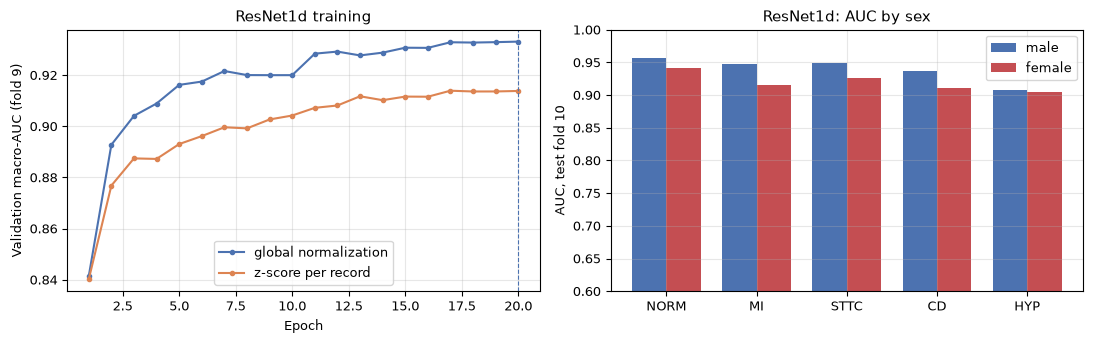

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist.epoch, hist.val_macro_auc, marker='o', ms=3, color='#4C72B0', label='global normalization')
ax[0].plot(hist_pr.epoch, hist_pr.val_macro_auc, marker='o', ms=3, color='#DD8452', label='z-score per record')
ax[0].axvline(best_epoch, color='#4C72B0', ls='--', lw=0.8)
ax[0].set(xlabel='Epoch', ylabel='Validation macro-AUC (fold 9)', title='ResNet1d training')
ax[0].legend()
x = np.arange(len(SUPERCLASSES))
auc_tab = res.pivot(index='class', columns='group', values='AUC').loc[SUPERCLASSES]
for k, (g, color) in enumerate((('male', '#4C72B0'), ('female', '#C44E52'))):
    ax[1].bar(x + (k - 0.5) * 0.38, auc_tab[g], 0.38, label=g, color=color)
ax[1].set_xticks(x, SUPERCLASSES)
ax[1].set(ylim=(0.6, 1.0), ylabel='AUC, test fold 10', title='ResNet1d: AUC by sex')
ax[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'w5_training_sex.png', dpi=150)
plt.show()

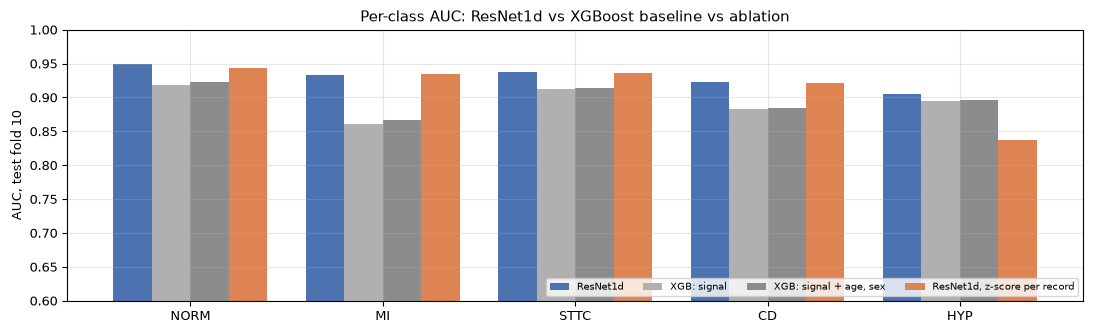

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.4))
models_cmp = per_class.copy()
models_cmp['ResNet1d, z-score per record'] = ablation.loc[SUPERCLASSES, 'z-score per record']
colors = ['#4C72B0', '#B0B0B0', '#8C8C8C', '#DD8452']
w = 0.2
for k, (col, color) in enumerate(zip(models_cmp.columns, colors)):
    ax.bar(x + (k - 1.5) * w, models_cmp[col], w, label=col, color=color)
ax.set_xticks(x, SUPERCLASSES)
ax.set(ylim=(0.6, 1.0), ylabel='AUC, test fold 10', title='Per-class AUC: ResNet1d vs XGBoost baseline vs ablation')
ax.legend(fontsize=7, ncol=4, loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR + 'w5_model_comparison.png', dpi=150)
plt.show()

In [12]:
np.savez(CACHE + 'resnet1d_scores.npz', s_val=s_val, s_test=s_test, s_test_per_record=s_test_pr)
hist.to_csv(CACHE + 'resnet1d_history.csv', index=False)
print('сохранено: resnet1d_global.pt, resnet1d_scores.npz, resnet1d_history.csv')

сохранено: resnet1d_global.pt, resnet1d_scores.npz, resnet1d_history.csv


## Выводы недели 5

**Baseline воспроизведён.** `ResNet1d` (510 тыс. параметров, вариант `resnet1d_wang`) на `records100`:
test macro-AUC **0.930 [0.923–0.936]** — ровно уровень опубликованного бенчмарка (0.930, Strodthoff et al.,
2021), то есть пайплайн недель 3–4 корректен и сопоставим с литературой. Лучшая эпоха — 20-я (val 0.933);
кривая к концу почти выходит на плато, поэтому больше эпох дали бы немного. Обучение на CPU — 39 минут.
(Время второй модели в выводе, 153 минуты, завышено: компьютер уходил в спящий режим.)

**CNN против признаков.** Сеть на +0.033 [0.027–0.038] macro-AUC лучше XGBoost недели 4 (0.897), выигрыш
есть по всем классам; сильнее всего — по MI (0.933 против 0.867): инфаркт требует морфологии комплексов,
которую статистики сигнала не передают.

**Абляция нормировки подтвердила вывод недели 3.** При z-score каждой записи качество падает только по
HYP: 0.905 → 0.837 (−0.068 [0.048–0.086]); остальные классы меняются в пределах ±0.006. Это ровно тот
эффект, который предсказал простой анализ амплитуды: нормировка записи на её собственное СКО стирает
вольтажные критерии гипертрофии. Нормировка по статистике обучающих фолдов закрепляется для всех моделей.

**Разрыв по полу у CNN больше, чем у признаковой модели.** macro-AUC у мужчин 0.939, у женщин 0.920 (у
XGBoost 0.904 и 0.891). Значимо ниже у женщин MI (−0.032 [−0.054; −0.010]) и STTC (−0.022 [−0.044; −0.002]),
без поправки на множественные сравнения. При одном пороге скрининга, подобранном на валидации для всех,
чувствительность у женщин ниже по MI (0.866 против 0.949), CD (0.848 против 0.925) и HYP (0.858 против
0.904). Это главный содержательный результат недели и прямое продолжение года 1: более сильная модель
не устраняет асимметрию по полу, а усиливает её, и общий порог систематически недодиагностирует
женщин.

## План на неделю 6

1. Пороги скрининга, подобранные отдельно по полу на фолде 9: проверить, выравнивается ли
   чувствительность без потери специфичности.
2. Причины разрыва по MI у женщин: доля женщин среди MI в обучении (37.7 %), возраст, качество сигналов —
   стратифицированный анализ ошибок.
3. Повторить обучение с другими seed (3 запуска), чтобы отделить разрыв по полу от разброса обучения;
   начать подбор гиперпараметров 1D-CNN (длина окна, ширина сети) из календарного плана недели 7.